In [1]:
# This code works in Python 3.10.6
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
import torch_geometric.transforms as T
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

In [2]:
import torch
from torch_geometric.datasets.dblp import DBLP
import os
import os.path as osp

Read DBLP dataset

In [3]:
dataset = DBLP(root='./dblp_data', transform=T.Constant(node_types='conference'))
data = dataset[0]
data

HeteroData(
  author={
    x=[4057, 334],
    y=[4057],
    train_mask=[4057],
    val_mask=[4057],
    test_mask=[4057],
  },
  paper={ x=[14328, 4231] },
  term={ x=[7723, 50] },
  conference={
    num_nodes=20,
    x=[20, 1],
  },
  (author, to, paper)={ edge_index=[2, 19645] },
  (paper, to, author)={ edge_index=[2, 19645] },
  (paper, to, term)={ edge_index=[2, 85810] },
  (paper, to, conference)={ edge_index=[2, 14328] },
  (term, to, paper)={ edge_index=[2, 85810] },
  (conference, to, paper)={ edge_index=[2, 14328] }
)

In [4]:
data['author'].x

tensor([[0., 0., 1.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [5]:
torch.unique(data['author'].x)

tensor([0., 1.])

In [6]:
data['paper'].x

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [7]:
torch.unique(data['paper'].x)

tensor([0., 1., 2., 3., 4., 5.])

In [8]:
data['term'].x

tensor([[-0.6924, -0.4659,  1.1540,  ...,  0.9178,  0.1995, -0.6360],
        [ 1.2031, -0.4003,  0.0740,  ...,  1.3262, -0.3325,  0.8198],
        [ 0.3748,  0.5731,  0.4802,  ...,  1.1522,  0.6010, -0.4309],
        ...,
        [ 0.4180,  0.2497, -0.4124,  ..., -0.1841, -0.1151, -0.7858],
        [ 0.1724, -0.2723, -1.3368,  ..., -0.0881,  0.0225,  0.1166],
        [ 0.2197,  0.0253,  0.1220,  ...,  0.0871, -0.5351, -0.4949]])

In [9]:
data['conference'].num_nodes

20

Training data for GMM 

In [10]:
#Original author node features
author = data['author'].x.tolist()
author_df = pd.DataFrame(author)
author_df['class'] = data['author'].y.tolist()

Fit GMM to 4 author types

In [11]:
author_class0 = author_df[author_df['class'] == 0].drop(['class'], axis = 1)
author_class0.shape[0]

1197

In [12]:
author_class1 = author_df[author_df['class'] == 1].drop(['class'], axis = 1)
author_class1.shape[0]

745

In [13]:
author_class2 = author_df[author_df['class'] == 2].drop(['class'], axis = 1)
author_class2.shape[0]

1109

In [14]:
author_class3 = author_df[author_df['class'] == 3].drop(['class'], axis = 1)
author_class3.shape[0]

1006

In [15]:
#Original paper node features
paper = data['paper'].x.tolist()
paper_df = pd.DataFrame(paper)

In [16]:
#Original term node features
term = data['term'].x.tolist()
term_df = pd.DataFrame(term)

Fit and sample GMM

In [17]:
new_features_dict = {}

In [18]:
def sample_features(model,node_type, n_samples):

    smpls = model.sample(n_samples)
    print("no of class {} node samples - {}".format(node_type, n_samples))
    return smpls[0]

In [19]:
def fit_sample_gm(df_class, node_type, n_samples):
    #fit
    model = GaussianMixture(n_components=1, covariance_type='full', random_state = 0)
    model.fit(df_class)

    #sample
    smpls = sample_features(model, node_type, n_samples)
    new_features_dict[node_type] = smpls

Class 1 - Author,
Class 0 - Paper,
Class 2 - Term,
Class 3 - Conference

In [20]:
fit_sample_gm(author_class0, 'author0', author_class0.shape[0])

no of class author0 node samples - 1197


In [21]:
fit_sample_gm(author_class1, 'author1', author_class1.shape[0])

no of class author1 node samples - 745


In [22]:
fit_sample_gm(author_class2, 'author2', author_class2.shape[0])

no of class author2 node samples - 1109


In [23]:
fit_sample_gm(author_class3, 'author3', author_class3.shape[0])

no of class author3 node samples - 1006


In [24]:
fit_sample_gm(paper_df, 'paper', paper_df.shape[0])

no of class paper node samples - 14328


In [25]:
fit_sample_gm(term_df, 'term', term_df.shape[0])

no of class term node samples - 7723


Plot node feature distributions

In [26]:
new_features_dict

{'author0': array([[-0.53202077, -0.11451794,  0.03972733, ...,  0.07034736,
         -0.08845135,  0.07814282],
        [ 0.09251921,  0.40770018, -0.00501428, ..., -0.01640461,
         -0.02354932,  0.58584887],
        [ 0.03204444,  0.48243233,  0.02709211, ...,  0.03744712,
         -0.17843438, -0.31492099],
        ...,
        [ 0.04922554,  0.01417949, -0.12340858, ..., -0.01131745,
         -0.11243494,  0.55174589],
        [ 0.26193186,  0.39863666, -0.01177841, ..., -0.02510899,
          0.12694029,  0.77254489],
        [-0.17273535, -0.15975503, -0.03441247, ..., -0.04004433,
          0.22033927,  0.67763058]]),
 'author1': array([[-0.07743486,  0.08205665, -0.12138325, ...,  0.22072984,
         -0.13223758, -0.07727355],
        [-0.16477074,  0.14837825,  0.00269914, ...,  0.10475423,
          0.06365601,  0.18680886],
        [ 0.18598069,  0.27685242, -0.0048582 , ..., -0.16327911,
          0.03922716,  0.2569347 ],
        ...,
        [ 0.07047811,  0.0868742

In [27]:
def plot_dist(node_list0,node_list1,node_list2,node_list3):    

    fig, ax = plt.subplots(figsize=(7, 5))

    sns.distplot(node_list0, label='author 0', ax=ax , hist= False)
    sns.distplot(node_list1, label='author 1', ax=ax , hist= False)
    sns.distplot(node_list2, label='author 2', ax=ax , hist= False)
    sns.distplot(node_list3, label='author 3', ax=ax , hist= False)

    ax.set_title('Dist plots')
    ax.legend()
    plt.show()

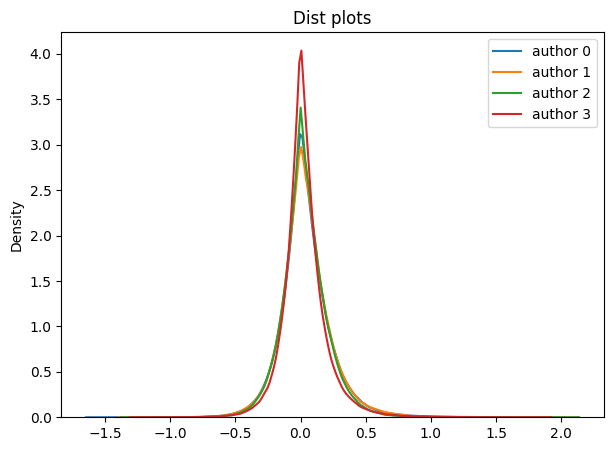

In [28]:
#Normal Distributions of 4 node types after fitting Gaussian Mixture Models 
plot_dist(new_features_dict['author0'],new_features_dict['author1'],new_features_dict['author2'],new_features_dict['author3'])

Setting to 0.0 if value is less than 0.5 else 1.0

In [29]:
def convert_to_binary(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0)

In [30]:
def convert_to_discrete(df):
    return df.applymap(lambda x: 0.0 if x<0.5 else 1.0 if 0.5>=x<0.6 
                       else 2.0 if 0.6>=x<0.7 else 3.0 if 0.7>=x<0.8 else 4.0 if 0.8>=x<0.9 
                       else 5.0 if 0.9>=x<1.0 else 1.0)

In [32]:
#Author

In [33]:
authorclass0_sampled = convert_to_binary(pd.DataFrame(new_features_dict['author0']))

In [34]:
authorclass1_sampled = convert_to_binary(pd.DataFrame(new_features_dict['author1']))

In [35]:
authorclass2_sampled = convert_to_binary(pd.DataFrame(new_features_dict['author2']))

In [36]:
authorclass3_sampled = convert_to_binary(pd.DataFrame(new_features_dict['author3']))

In [37]:
#Paper

In [38]:
paper_node_features = convert_to_discrete(pd.DataFrame(new_features_dict['paper']))

In [39]:
#paper_node_features

In [40]:
np.unique(paper_node_features)

array([0., 1., 2., 3., 4., 5.])

In [41]:
#Term

In [42]:
term_node_features = pd.DataFrame(new_features_dict['term'])
term_node_features

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,0.114303,-0.021150,-0.467590,-0.482671,-0.575370,1.069572,2.496041,0.077327,-0.117388,0.722236,...,-0.131720,0.008904,0.138412,0.558177,0.408442,0.123478,1.182760,-0.254246,0.249748,-0.102261
1,0.165329,0.402683,0.488253,-0.206850,0.110398,-0.981860,-1.027542,-0.057614,-0.126436,0.211618,...,0.505244,0.210251,0.100747,-0.469466,-0.451846,0.241061,0.019800,0.806796,-0.053657,-0.179553
2,0.223405,-1.052909,-0.778101,-0.434453,-0.416367,0.472973,0.806147,-0.326207,-0.027566,0.508469,...,1.015090,0.971593,-0.945699,0.922814,0.529682,0.183336,0.872085,-0.273031,-0.053679,0.305093
3,-0.401467,-0.153163,-0.185548,-0.810712,0.422185,-0.666402,0.544468,-0.249976,-0.294757,0.041697,...,-0.394668,-0.729762,0.445982,0.702947,0.122313,-0.457759,0.380258,1.369012,-0.438447,-0.000273
4,0.617280,-0.255000,-0.327735,-0.079130,0.713097,-0.127952,0.992902,0.014097,0.709155,-0.811864,...,-0.266757,-0.391192,-0.360417,0.237729,-0.090947,-0.068364,0.332297,-1.025699,0.333142,-0.935395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7718,0.742263,0.549813,-0.974856,0.836168,-0.355973,-0.316076,-0.742202,0.412882,-0.355016,-0.654021,...,-0.712332,-0.631995,0.204774,0.727300,-0.261252,0.645273,-0.155726,-0.198046,-0.848852,-0.457049
7719,0.536718,-0.641143,0.703050,-0.240442,0.734890,0.307949,0.853078,0.032112,-0.511773,1.080832,...,0.717807,0.981097,-0.197695,0.114503,-0.732201,0.071250,-0.939005,-0.021895,-0.433850,0.455252
7720,-0.052414,0.439078,-0.600169,0.023960,-0.487874,0.561972,0.189992,0.448284,-0.645302,0.594928,...,0.539237,0.285404,0.859282,0.785859,-0.526828,-0.528336,0.309851,-0.309566,-0.140963,0.123302
7721,0.868536,-0.172518,-0.245002,-0.409669,-0.680052,-0.998669,0.319671,-0.464253,-0.462924,-0.575000,...,-0.273558,-0.912719,0.053784,-0.681013,-0.961455,-0.139100,0.296257,0.281435,0.536770,0.276637
